In [1]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")
df.shape

(10000, 14)

In [3]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
df['Machine failure'].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

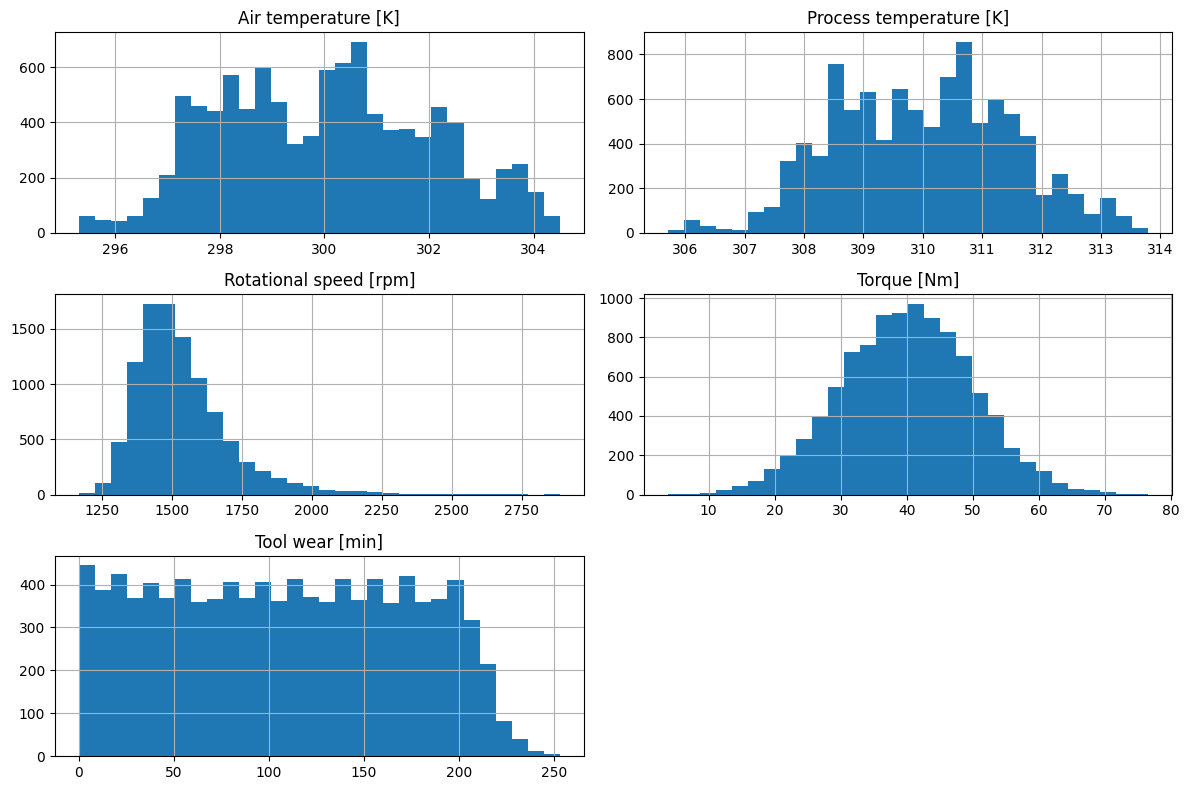

In [11]:
import matplotlib.pyplot as plt

df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 
    'Torque [Nm]', 'Tool wear [min]']].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

In [12]:
df.duplicated().sum()
df['Product ID'].duplicated().sum()

np.int64(0)

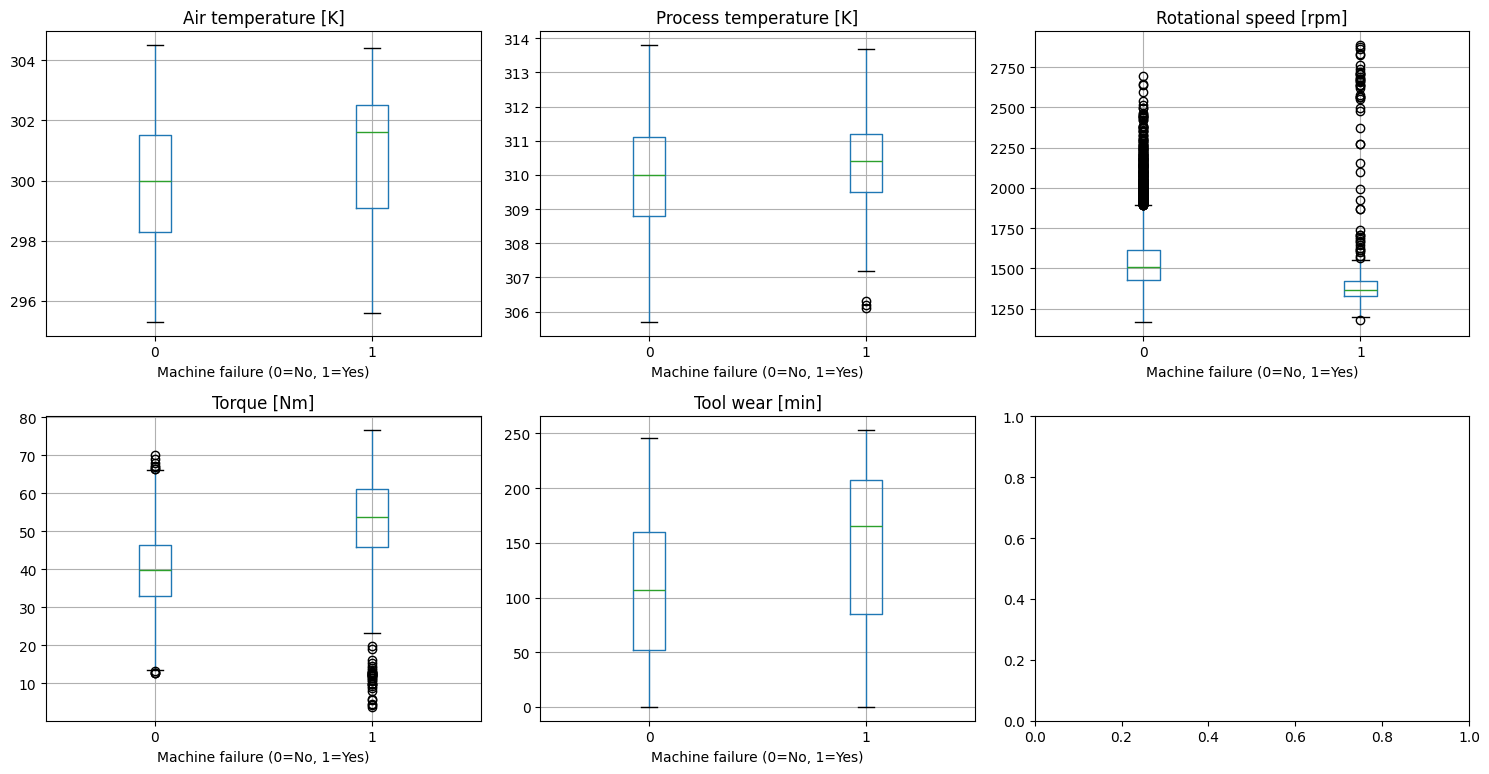

In [13]:
import matplotlib.pyplot as plt

features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='Machine failure', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Machine failure (0=No, 1=Yes)')

plt.suptitle('')  # removes default ugly title
plt.tight_layout()
plt.show()

In [14]:
df.groupby('Machine failure')['Torque [Nm]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


In [15]:
df['high_torque_flag'] = (df['Torque [Nm]'] > 46).astype(int)
df['high_torque_flag'].value_counts()


high_torque_flag
0    7252
1    2748
Name: count, dtype: int64

In [16]:
pd.crosstab(df['high_torque_flag'], df['Machine failure'], normalize='index') * 100


Machine failure,0,1
high_torque_flag,,
0,98.814120,1.185880
1,90.793304,9.206696


In [17]:
df.groupby('Machine failure')['Rotational speed [rpm]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
1,339.0,1496.486726,384.943547,1181.0,1326.5,1365.0,1421.5,2886.0


In [18]:
median_speed = df['Rotational speed [rpm]'].median()
print(median_speed)

df['speed_deviation'] = abs(df['Rotational speed [rpm]'] - median_speed)
df['speed_deviation'].describe()

1503.0


count    10000.000000
mean       124.405900
std        133.956965
min          0.000000
25%         44.000000
50%         91.000000
75%        156.000000
max       1383.000000
Name: speed_deviation, dtype: float64

In [19]:
df.groupby('Machine failure')['speed_deviation'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,120.158679,122.351324,0.0,43.0,88.0,153.0,1192.0
1,339.0,245.445428,296.314680,2.0,126.0,155.0,206.5,1383.0


In [23]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF',
 'high_torque_flag',
 'speed_deviation']

In [24]:
df.groupby('Machine failure')['Tool wear [min]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0
1,339.0,143.781711,72.759876,0.0,84.5,165.0,207.5,253.0


In [25]:
df['high_wear_flag'] = (df['Tool wear [min]'] > 165).astype(int)
df['high_torque_and_wear'] = ((df['high_torque_flag'] == 1) & (df['high_wear_flag'] == 1)).astype(int)
df['high_torque_and_wear'].value_counts()

high_torque_and_wear
0    9351
1     649
Name: count, dtype: int64

In [26]:
pd.crosstab(df['high_torque_and_wear'], df['Machine failure'], normalize='index') * 100

Machine failure,0,1
high_torque_and_wear,,
0,97.668699,2.331301
1,81.355932,18.644068
